# Stage 5 — Land-Use Pressure (Mole Creek prototype)

**Data access reused from AT2**: `pystac_client` search against DEA's public STAC catalogue, `odc.stac.load` to bring it in already reprojected to EPSG:7855. **What differs from AT2:** the resample and reclassify steps. AT2 used PyQGIS (`processing.run("gdal:warpreproject", ...)` and `processing.run("native:reclassifybytable", ...)`). Here both use `rioxarray`/`numpy`: reproject/resample via `.rio.reproject_match()` (nearest-neighbour, since land cover is categorical), and reclassify via a numpy lookup. The fetch and reclassify live in `src/landuse.py` as `fetch_landuse_pressure()`, shared with Stages 7 and 9.

Both DEA epochs (2010, 2020) are fetched so the change between them can be compared (Stage 9).


In [1]:
from pathlib import Path
import os
import sys

import geopandas as gpd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

mole_creek = gpd.read_file(str(outpath / "mole_creek_bounding_box_EPSG7855.gpkg"))
mole_creek_wgs84 = mole_creek.to_crs("EPSG:4326")  # DEA STAC search requires WGS84 lon/lat
bbox = mole_creek_wgs84.total_bounds.tolist()


## 5.1 Fetch + reclassify to a pressure scale

The fetch and reclassify live in `src/landuse.py` (`fetch_landuse_pressure`), shared with Stages 7 and 9. No authentication is needed: the STAC catalogue is public, with anonymous S3 access.

Level-3 classes present at Mole Creek: 111 (cultivated terrestrial vegetation), 112 (natural terrestrial vegetation), 215 (artificial surface), 216 (natural bare surface), 220 (water), 255 (no data). The scale is kept simple and transparent (per the revised workflow's land-use table), on the same 0-3 ordinal scale as the other layers:

| Level-3 class | Pressure score |
|---|---|
| 111 Cultivated terrestrial vegetation | 3 (High -- agriculture) |
| 112 Natural terrestrial vegetation | 1 (Low) |
| 124 Natural aquatic vegetation | 1 (Low) |
| 215 Artificial surface | 3 (High -- urban/development) |
| 216 Natural bare surface | 1 (Low -- natural, not human pressure) |
| 220 Water | 0 (None) |
| 255 No data | excluded |


In [2]:
dem_template_path = outpath / "dem_mc_EPSG7855.tif"

pressure_by_year = {}
for year in [2010, 2020]:
    pressure_aligned = fetch_landuse_pressure(bbox, year, dem_template_path)
    pressure_by_year[year] = pressure_aligned

    with rasterio.open(dem_template_path) as ref:
        profile = ref.profile.copy()
    profile.update(dtype="uint8", nodata=255, count=1)
    out_path = outpath / f"landuse_pressure_mc_{year}_EPSG7855.tif"
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(pressure_aligned, 1)

with rasterio.open(dem_template_path) as dem_src:
    dem_data = dem_src.read(1)
    dem_nodata_val = dem_src.nodata
valid = dem_data != dem_nodata_val

for year in [2010, 2020]:
    vals, counts = np.unique(pressure_by_year[year][valid], return_counts=True)
    print(f"Year {year} pressure distribution (valid cells):", dict(zip(vals.tolist(), counts.tolist())))


Year 2010 pressure distribution (valid cells): {0: 19193, 1: 1648545, 3: 180275, 255: 397}
Year 2020 pressure distribution (valid cells): {0: 20848, 1: 1544231, 3: 283006, 255: 325}


## 5.3 Visualise both epochs side by side

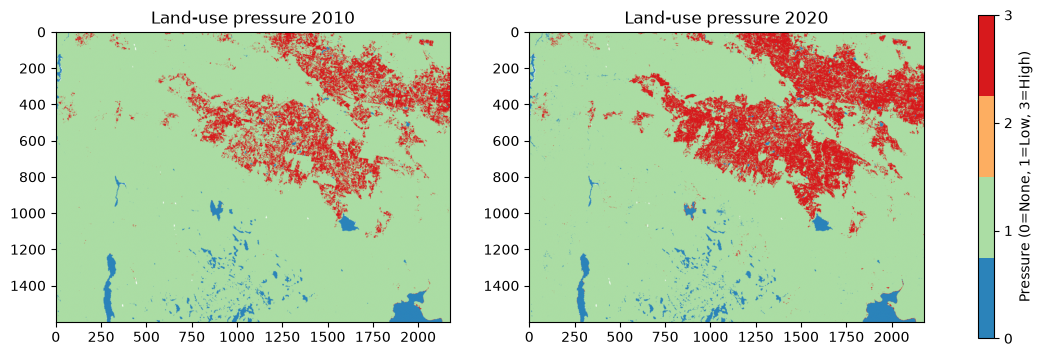

In [3]:
cmap = ListedColormap(["#2b83ba", "#abdda4", "#fdae61", "#d7191c"])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, year in zip(axes, [2010, 2020]):
    display = np.ma.masked_equal(pressure_by_year[year], 255)
    im = ax.imshow(display, cmap=cmap, vmin=0, vmax=3)
    ax.set_title(f"Land-use pressure {year}")
plt.colorbar(im, ax=axes, ticks=[0, 1, 2, 3], label="Pressure (0=None, 1=Low, 3=High)", shrink=0.7)
plt.show()

## An early look at the temporal trend

High-pressure (cultivated + artificial) area increased from 180,275 to 283,006 cells between 2010 and 2020 at Mole Creek, roughly a 57% increase within the buffered study area. Stage 9 extends this to the annual series (1988-2024), which shows 2010-2020 is one phase of a longer cycle.

## Stage 5 outputs

- `landuse_pressure_mc_2010_EPSG7855.tif`
- `landuse_pressure_mc_2020_EPSG7855.tif`

Both aligned to the same grid as Stages 2-4 (the Mole Creek DEM
template), so they're ready to combine directly.

**Next (Stage 6):** combine Stage 4 (intrinsic vulnerability) × Stage 5
(land-use pressure, 2020 as the primary year) into the final relative
vulnerability/risk map for Mole Creek — the prototype's main output,
before scaling statewide.